## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [2]:
import requests


# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230


url = f"https://api.open-meteo.com/v1/forecast?"  # Aquí vienen el resto de los parámetros

In [20]:
longitude = -2.92528
latitude = 43.26271

url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&hourly=temperature_2m,precipitation"
response = requests.get(url)
response.json()


{'latitude': 43.26,
 'longitude': -2.9300003,
 'generationtime_ms': 0.3260374069213867,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 21.0,
 'hourly_units': {'time': 'iso8601',
  'temperature_2m': '°C',
  'precipitation': 'mm'},
 'hourly': {'time': ['2026-03-23T00:00',
   '2026-03-23T01:00',
   '2026-03-23T02:00',
   '2026-03-23T03:00',
   '2026-03-23T04:00',
   '2026-03-23T05:00',
   '2026-03-23T06:00',
   '2026-03-23T07:00',
   '2026-03-23T08:00',
   '2026-03-23T09:00',
   '2026-03-23T10:00',
   '2026-03-23T11:00',
   '2026-03-23T12:00',
   '2026-03-23T13:00',
   '2026-03-23T14:00',
   '2026-03-23T15:00',
   '2026-03-23T16:00',
   '2026-03-23T17:00',
   '2026-03-23T18:00',
   '2026-03-23T19:00',
   '2026-03-23T20:00',
   '2026-03-23T21:00',
   '2026-03-23T22:00',
   '2026-03-23T23:00',
   '2026-03-24T00:00',
   '2026-03-24T01:00',
   '2026-03-24T02:00',
   '2026-03-24T03:00',
   '2026-03-24T04:00',
   '2026-03-24T05:00',
   '2026-03-24T0

In [21]:
horas = response.json().get("hourly", {}).get("time", [])
temperaturas = response.json().get("hourly", {}).get("temperature_2m", [])
precipitation = response.json().get("hourly", {}).get("precipitation", [])
print(horas[:5])
print(temperaturas[:5])
print(precipitation[:5])

['2026-03-23T00:00', '2026-03-23T01:00', '2026-03-23T02:00', '2026-03-23T03:00', '2026-03-23T04:00']
[12.4, 12.2, 11.9, 11.5, 11.1]
[0.0, 0.0, 0.0, 0.0, 0.2]


In [24]:
import pandas as pd

hourly_temp = pd.DataFrame({"hora": horas, "temperatura": temperaturas, "precipitation": precipitation})
hourly_temp.head(50)

,hora,temperatura,precipitation
0,2026-03-23T00:00,12.4,0.0
1,2026-03-23T01:00,12.2,0.0
2,2026-03-23T02:00,11.9,0.0
3,2026-03-23T03:00,11.5,0.0
4,2026-03-23T04:00,11.1,0.2
5,2026-03-23T05:00,10.9,0.4
6,2026-03-23T06:00,11.0,0.0
7,2026-03-23T07:00,11.3,0.1
8,2026-03-23T08:00,12.0,0.0
9,2026-03-23T09:00,13.1,0.0


<Axes: xlabel='hora', ylabel='temperatura'>

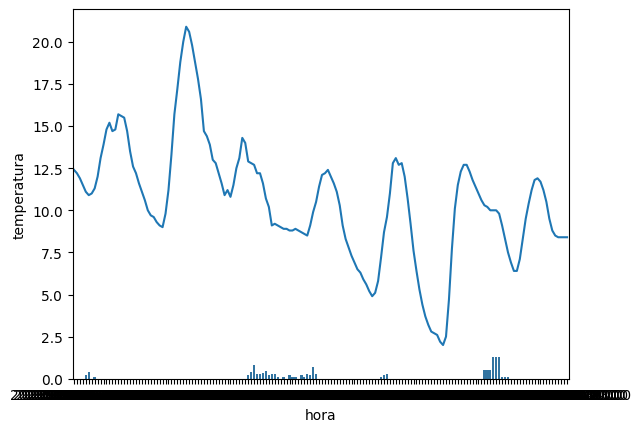

In [25]:
import seaborn as sns

sns.lineplot(data=hourly_temp, x="hora", y="temperatura")
sns.barplot(data=hourly_temp, x="hora", y="precipitation")